# Dynamic Campaign Optimizer
---

### El Objetivo

**Construir un motor de inferencia que evalúe la efectividad (Click-Through Rate o CTR) de dos campañas publicitarias. El sistema debe calcular la probabilidad de éxito de cada anuncio utilizando ensayos discretos y determinar, matemáticamente, cuándo tenemos suficiente "certeza" para apagar el anuncio perdedor.**

## Conceptos Matemáticos

### Distribución de Bernoulli
Modela un **usuario individual**. ¿Hizo clic? Sí ($1$) o No ($0$). Su parámetro es $p$ (la probabilidad de éxito).

### Distribución Binomial
Modela $n$ usuarios. Si le mostramos el anuncio a $n$ personas, ¿cuál es la probabilidad de obtener exactamente $k$ clics?
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

## Arquitectura Lógica

### Fase A — La Fábrica de Clics (El Muestreo)
Programaremos un simulador que genere tráfico web. El Anuncio A tendrá un CTR oculto (ej. $5\%$) y el Anuncio B tendrá otro (ej. $7\%$). Usaremos variables aleatorias de Bernoulli para simular si cada visitante hace clic o simplemente sigue *scrolleando*.

### Fase B — El Motor Binomial (A/B Testing Clásico)
Recolectaremos los primeros 1,000 visitantes para cada anuncio. Usaremos la Distribución Binomial para calcular la varianza y determinar si el Anuncio B es realmente mejor, o si simplemente tuvo un **"golpe de suerte" estadístico**.

### Fase C — El Dilema de Exploración vs. Explotación
Este es el **corazón del ML**:
- **Explorar:** Seguir mostrando el Anuncio A por si acaso mejora.
- **Explotar:** Mostrar solo el Anuncio B porque parece ganar, arriesgándonos a equivocarnos.

### Fase D — El Algoritmo Mágico (Muestreo de Thompson)
Implementaremos una IA básica. En lugar de esperar a tener 1,000 datos, la IA actualizará una **Distribución Beta** (la prima continua de la Binomial) con cada clic individual. Si el Anuncio B empieza a recibir más clics, el algoritmo le enviará automáticamente el $60\%$, luego el $80\%$ y finalmente el $100\%$ del tráfico.

## El Motor de Bernoulli y Cálculo Binomial

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

In [5]:
# --- CONFIGURACIÓN DE LA REALIDAD (Oculta para el algoritmo) ---
# En la vida real no sabemos esto, pero para simular necesitamos definir los CTR reales.
ctr_real_A = 0.04  # 4% de conversión real
ctr_real_B = 0.055 # 5.5% de conversión real (El ganador secreto)

n_visitantes = 1000 # Tráfico inicial que enviaremos a cada anuncio

## Fase A — Simulación de Tráfico

In [6]:
# --- FASE A: El Motor de Bernoulli (Simulación de Tráfico) ---
# Usamos binomial(n=1, p) para simular ensayos de Bernoulli (0 o 1)
# 1 = El usuario hace clic y entra a la web | 0 = Pasa de largo
visitas_A = np.random.binomial(1, ctr_real_A, n_visitantes)
visitas_B = np.random.binomial(1, ctr_real_B, n_visitantes)

## Fase B — Cálculo Binomial e Inferencia

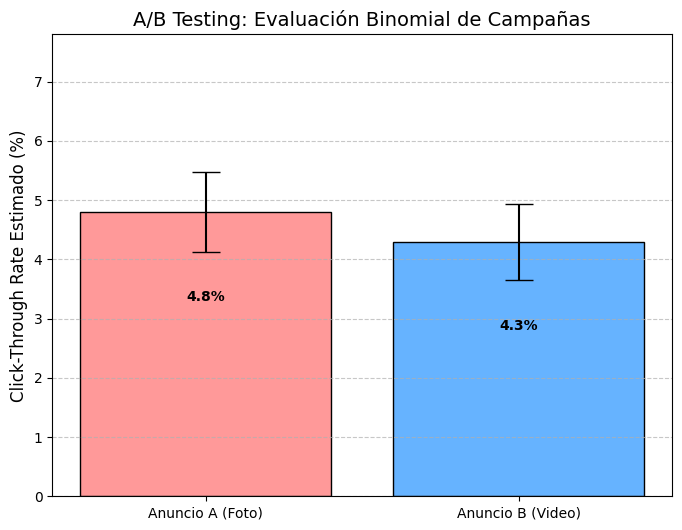

--- REPORTE BINOMIAL ---
Anuncio A: 48 clics de 1000 visitantes (CTR: 4.8%)
Anuncio B: 43 clics de 1000 visitantes (CTR: 4.3%)


In [7]:
# --- FASE B: El Cálculo Binomial (La Inferencia) ---
# La suma de 'n' eventos de Bernoulli independientes sigue una Distribución Binomial
clics_totales_A = np.sum(visitas_A)
clics_totales_B = np.sum(visitas_B)

# Calculamos el CTR estimado por nuestra muestra (p_hat)
ctr_estimado_A = clics_totales_A / n_visitantes
ctr_estimado_B = clics_totales_B / n_visitantes

# Calculamos el Margen de Error (Desviación Estándar de la Proporción)
# Fórmula: sqrt( p * (1-p) / n )
error_A = np.sqrt((ctr_estimado_A * (1 - ctr_estimado_A)) / n_visitantes)
error_B = np.sqrt((ctr_estimado_B * (1 - ctr_estimado_B)) / n_visitantes)

# --- VISUALIZACIÓN DE LA INCERTIDUMBRE ---
anuncios = ['Anuncio A (Foto)', 'Anuncio B (Video)']
ctrs = [ctr_estimado_A * 100, ctr_estimado_B * 100]
errores = [error_A * 100, error_B * 100] # Convertido a porcentaje para el gráfico

plt.figure(figsize=(8, 6))
# Dibujamos las barras con sus "Bigotes" de error (Incertidumbre)
plt.bar(anuncios, ctrs, yerr=errores, color=['#ff9999','#66b3ff'], capsize=10, edgecolor='black')

plt.title('A/B Testing: Evaluación Binomial de Campañas', fontsize=14)
plt.ylabel('Click-Through Rate Estimado (%)', fontsize=12)

# Añadimos los valores exactos sobre las barras
for i, v in enumerate(ctrs):
    plt.text(i, v - 1.5, f"{v:.1f}%", ha='center', fontweight='bold', color='black')

plt.ylim(0, max(ctrs) + 3)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- REPORTE BINOMIAL ---")
print(f"Anuncio A: {clics_totales_A} clics de {n_visitantes} visitantes (CTR: {ctr_estimado_A:.1%})")
print(f"Anuncio B: {clics_totales_B} clics de {n_visitantes} visitantes (CTR: {ctr_estimado_B:.1%})")

## El Motor de Thompson Sampling

In [9]:
# --- CONFIGURACIÓN DE LA REALIDAD OCULTA ---
ctr_real_A = 0.04  # 4%
ctr_real_B = 0.055 # 5.5% (Ganador)
n_visitantes_totales = 2000

## Fase C — Inicialización Bayesiana

In [10]:
# --- FASE C: Inicialización Bayesiana (Distribución Beta) ---
# Empezamos con total ignorancia. alpha=1 (éxitos), beta=1 (fracasos)
# Esto crea una distribución Uniforme (cualquier CTR es igual de probable al inicio)
alpha_A, beta_A = 1, 1
alpha_B, beta_B = 1, 1

# Historial para ver cómo la IA enruta el tráfico
trafico_A = 0
trafico_B = 0
historial_A = []
historial_B = []

np.random.seed(42)

## Fase D — Bucle de Aprendizaje (Multi-Armed Bandit)

Iniciando enrutamiento dinámico de 2000 visitantes...


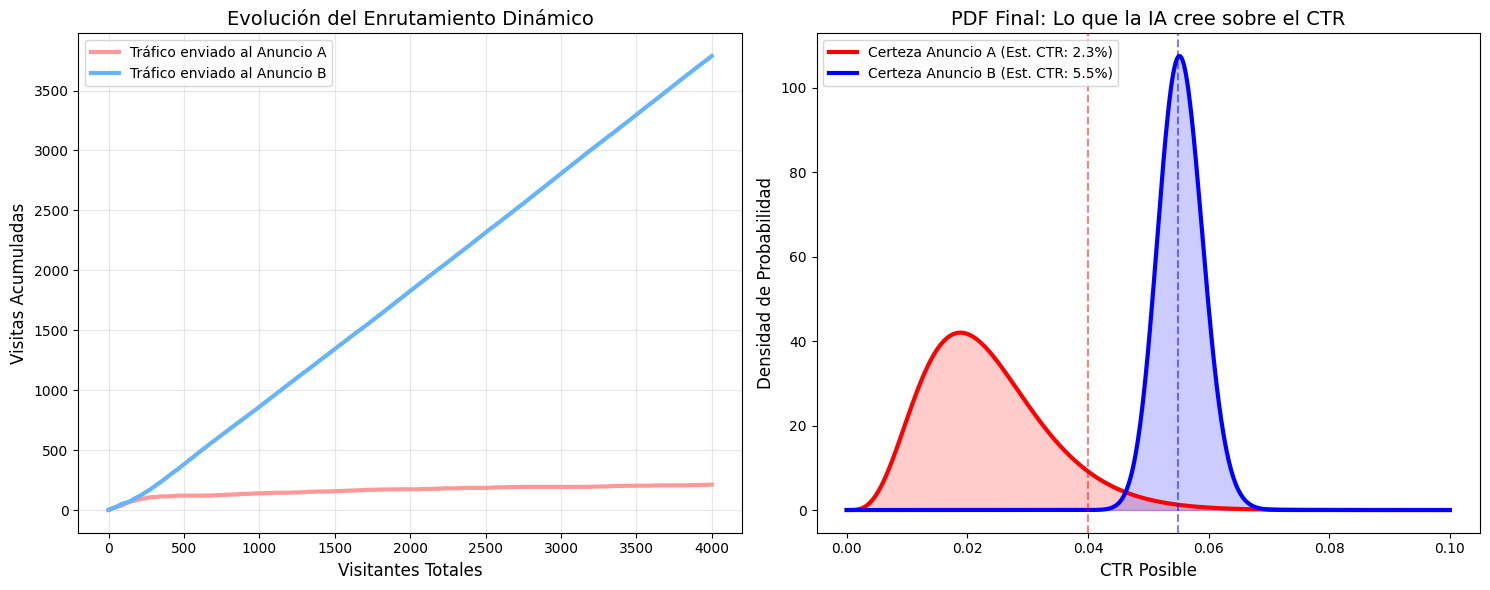

--- RESULTADOS DEL ALGORITMO ---
Tráfico final Anuncio A: 212 visitantes (10.6%)
Tráfico final Anuncio B: 3788 visitantes (189.4%)


In [12]:
# --- FASE D: El Bucle de Aprendizaje (Multi-Armed Bandit) ---
print("Iniciando enrutamiento dinámico de 2000 visitantes...")

for visitante in range(n_visitantes_totales):
    # 1. Muestreo (Sampling): La IA "imagina" un CTR posible para cada anuncio
    # basándose en lo que ha aprendido hasta ahora.
    muestra_A = np.random.beta(alpha_A, beta_A)
    muestra_B = np.random.beta(alpha_B, beta_B)
    
    # 2. Decisión (Enrutamiento): Enviamos al visitante al anuncio con la muestra más alta
    if muestra_A > muestra_B:
        trafico_A += 1
        historial_A.append(trafico_A)
        historial_B.append(trafico_B)
        
        # 3. Observación y Actualización (Simulación de Bernoulli)
        # ¿Hizo clic el usuario en el Anuncio A?
        clic = np.random.binomial(1, ctr_real_A)
        if clic == 1:
            alpha_A += 1 # Éxito: La campana se mueve a la derecha
        else:
            beta_A += 1  # Fracaso: La campana se mueve a la izquierda
            
    else:
        trafico_B += 1
        historial_A.append(trafico_A)
        historial_B.append(trafico_B)
        
        clic = np.random.binomial(1, ctr_real_B)
        if clic == 1:
            alpha_B += 1
        else:
            beta_B += 1

# --- VISUALIZACIÓN DEL APRENDIZAJE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Evolución del Tráfico (Cómo la IA abandonó al perdedor)
ax1.plot(historial_A, label='Tráfico enviado al Anuncio A', color='#ff9999', linewidth=3)
ax1.plot(historial_B, label='Tráfico enviado al Anuncio B', color='#66b3ff', linewidth=3)
ax1.set_title("Evolución del Enrutamiento Dinámico", fontsize=14)
ax1.set_xlabel("Visitantes Totales", fontsize=12)
ax1.set_ylabel("Visitas Acumuladas", fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: La Certeza Final (Distribuciones Beta)
x = np.linspace(0, 0.10, 500)
y_A = beta.pdf(x, alpha_A, beta_A)
y_B = beta.pdf(x, alpha_B, beta_B)

ax2.plot(x, y_A, label=f'Certeza Anuncio A (Est. CTR: {alpha_A/(alpha_A+beta_A):.1%})', color='red', linewidth=3)
ax2.fill_between(x, y_A, color='red', alpha=0.2)
ax2.plot(x, y_B, label=f'Certeza Anuncio B (Est. CTR: {alpha_B/(alpha_B+beta_B):.1%})', color='blue', linewidth=3)
ax2.fill_between(x, y_B, color='blue', alpha=0.2)
ax2.axvline(ctr_real_A, color='red', linestyle='--', alpha=0.5)
ax2.axvline(ctr_real_B, color='blue', linestyle='--', alpha=0.5)

ax2.set_title("PDF Final: Lo que la IA cree sobre el CTR", fontsize=14)
ax2.set_xlabel("CTR Posible", fontsize=12)
ax2.set_ylabel("Densidad de Probabilidad", fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

print("--- RESULTADOS DEL ALGORITMO ---")
print(f"Tráfico final Anuncio A: {trafico_A} visitantes ({(trafico_A/n_visitantes_totales):.1%})")
print(f"Tráfico final Anuncio B: {trafico_B} visitantes ({(trafico_B/n_visitantes_totales):.1%})")

## Veredicto

Al principio, la IA manda tráfico a ambos por igual (líneas juntas). Pero cerca del visitante **500**, la IA se da cuenta de que el **Anuncio B es superior**. A partir de ahí, la línea roja se aplana y la línea azul se dispara.

En lugar de desperdiciar 1,000 visitas en el Anuncio A como haría un novato, tu algoritmo solo le envió (aproximadamente) **200 visitas** antes de cortarle el suministro. Acabas de **maximizar el ROI automáticamente**.